<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #7c3aed; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Clustering Particional: K-Means y sus Variantes 🎯🔵
      </h1>
      <p style="margin: 6px 0 0 0; color: #7c3aed; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Unsupervised Learning — Partitional Clustering
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/00_Clustering_Particional_KMeans.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Fundamento Matemático de K-Means (Lloyd, 1957) ⚙️

K-Means particiona un conjunto $X = \{x_1, \ldots, x_n\} \subset \mathbb{R}^p$ en $K$ grupos disjuntos minimizando la **inercia** (WCSS — *Within-Cluster Sum of Squares*):

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

donde $\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$ es el centroide del cluster $k$.

El algoritmo de Lloyd itera dos pasos hasta convergencia:

| Paso | Operación | Complejidad |
|------|-----------|-------------|
| **E-step** (Asignación) | $c_i \leftarrow \arg\min_k \|x_i - \mu_k\|^2$ | $O(nKp)$ por iteración |
| **M-step** (Actualización) | $\mu_k \leftarrow \text{media de los puntos asignados a } k$ | $O(np)$ por iteración |

### 1.1 Propiedades y Limitaciones

* **Convergencia garantizada** a un mínimo local en tiempo finito (el número de particionamientos posibles es finito).
* **Sensible a inicialización**: diferentes semillas pueden producir soluciones locales muy distintas.
* **K-Means++ (Arthur & Vassilvitskii, 2007)**: inicialización probabilística que garantiza $O(\log K)$-aproximación al óptimo global en valor esperado. Es el default en scikit-learn.
* **Supuesto de convexidad**: asume clusters esféricos de tamaño similar. Falla con clusters elongados, de densidad variable o con ruido.

### 1.2 El Método del Codo y la Selección de K

No existe un valor "verdadero" de $K$ en datos reales. Se usan criterios heurísticos:

| Criterio | Fórmula / Descripción | Interpretación |
|----------|-----------------------|----------------|
| **Inercia (WCSS)** | $J(K)$ decreciente | "Codo" donde la ganancia marginal cae abruptamente |
| **Silhouette Score** | $\bar{s} \in [-1, 1]$ (ver Notebook 03) | Máximo indica separación óptima |
| **Gap Statistic** | Compara con referencia uniforme | Selecciona K con mayor gap |
| **Índice Davies-Bouldin** | Compacidad vs. separación | Mínimo es mejor |

> **Regla práctica en contexto de negocio:** Combinar el codo con la interpretabilidad de los segmentos. Un modelo con $K=5$ "segmentos de cliente" puede ser más accionable que uno con $K=8$ aunque tenga menor inercia.


In [1]:
# ─── Celda 1: Configuración y carga de datos ──────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import os, sys
import warnings
warnings.filterwarnings('ignore')

# Cargar setup_colab (función load_dataset con fallback embebido)
exec(open(os.path.join(os.path.dirname(os.path.abspath('.')), 'setup_colab.py') if os.path.exists(
    os.path.join(os.path.dirname(os.path.abspath('.')), 'setup_colab.py')) else 'setup_colab.py').read()) \
    if False else None

# Definición inline de load_dataset por compatibilidad
import os, sys, urllib.request, urllib.parse, gzip, base64

# ─── Datos embebidos (fallback sin conexión a GitHub) ─────────────────────────
_DATA_EMBEDDED = {
    "segmentacion_clientes_tienda.csv": "H4sIAAq1mGoC/21dS69uR06dI/FPDtJ2vT1mygwYR1F31IqANCJpfj/ltfZ328uH6CqDqv3V0+Xnss+vf/7pT//56y+//fHL1y9//vnPX7/+9pf/+eX3v/70829/+/k/f/qPn/72+5+//vtvv/3xt5//9Otff/vpLz///sdfv/73199//ePn33/6r19++/1+9svv//gP//wv//6v//ZPz/3Pvtr6sra/9vlauaN9zf3lt3F+tdzev2b7au3LxlfP7eNr9K9jX/Nr5+YZ367+5fPLcvv66s+X2RMdMv7+WnfwfuceXzN3nK+x70pb9MsvPFZq/U4gO7hjL7bf6fNIdhd593x3Ev254w680dEeHeoO4HfuE3scuePu+vm67WfqD2Y07hWbyKdk66thuaPpknYcx7D4XlZ0sLd7Rcv1B/61Fs5vD1lRrLzHSOdou8UPTvvqLqcX53mwtXus8oP+1fud4a71yNRtBMmcuwBtnrHGWOrWPd+Whksdem+3cSxQTBn/xPh3meWs4+CeINO76TwOD87uYo+eUbcg1X7iN3mg3uJyYn96FHeESxdB2l020AcI5Z7E1lu+pBVEfAkwVps7VpAFSNK0Aze/77kubT8xxV1wL1N7tFwSWI+039Hvu4yZXQe6J3HHutc8dW+DpH0qudwzvsdvl16nyeGNEdPGYUxtv3tecU7n0fYVhx2k14UB3Dd7f3KpMq47t5+Y+GwceW6/NOTReHecv79Xf+n0rLrhu+wBQtp6QhP869LM7c3rnHj1d5Cjn2O7dtlhYRYTDOyAuPLd3xXerng3++vJ7TuOPt6f6QR3vnuYZpWv3a/vmu5pNhn/br894IOmB7cM5H479SbvA8NNrng9eYK7oUsrl+a2bnmNaA9y1Hd5G29XUKQLL7rsY0IcKEHc07w9PZpl9IPDn19+jyK3X7qcOEwl0Lg+w8Qy+rYY2kJc6CO+i14GduN6DnejcYWXjwodBlPa8TDKMBMvtQUD0e/JCe4xH2VnG8/ovvutMmKDg/oTTCpveHusx57bKt/fG7+EbsFrlNIPuEAsaegTO5C7d/47ZF7RASfbEAX5wu7C70pDAnVtn3E1wReV2dzH1RdWNJUW7ysNBtdioHxnV8SEWOygLpnBeTlg1/kXjldsD15g3tulkktZ7nFJeU1+Jx2UKvq+Hedm/ZtkjOdF6T506hnUGFy88NK7knhMM95g3oSD/d2TuseaL/TqRDPuZ4Jgc4fHE7+Tx1R/b4+rjz3cc1WdCdzG8GTvpbbcAU6KzcmasKsVr2SJzLSrfQUJ35lCVcgddylxRfcahv5iQYEAq31yO84nKDk/B7vaV3DCjdeY2z0mDvYrNBmKyb2eS8pNt3z5X6h2Pc4uj3NVr7srCPGuP+hkABNcJncMbODOskQihCwDjc3gk3nL95yDNY+g8nzalyQuu2i4JRkILKzzX27HWxiQCvmsg4p2KH1NFJd4yZcu+ioEFqpscP4WS8rrvD9veKL70fYRVBpMQS+fmteG4Ml3Ri0qtJ2l34NjH5C3tOOO7zhHBIU1KCEbOk3e1z16KEtP0X6tQ4rejamos3gdBvXedKAeC7r3r+d8r4PrMRFQwW9C4+6xLxkG9BzHd8k9HzS1rrhgXeZ5pd996fnc7qHdq4/Vmsg0i/1DAg6xG+zSWeMp6+eNOoUHeeWJr4rU8PTLmxx41y20blnQgA7SqnZoAzIqzC5lH3d598vLOlUg2F18WEMTBkhu93jzwdeazDufD/Nd+jImNOtVVXQLdXvSqmuy0okdbxiI8gPs+NL50BO69x6LXSFP5fsV7fH2Vde30PUWrMOggtxxMFKIcv2BQ5iCX+cZ7kFMqA961OsVyjvEez7rBVUbNqPrQNCsQ6wcbYc8vlsujO5eS9ApHnI+iuBuG0qKcvardw1yj0cu7Z5n8EVq3LJSx9lRlOYj2jCU/RSj1Db41oAJKu24eg/LR3awsePLDroIfdt4x/EKlW9d3eu2h7AWzcg2xV61beweTIcNZlvnBeFOGBTS7uBYXgXEZcPQTsB489EdKKAhOU7pAJlcbqDWk90rHMHNQlpKOyzGCdNZ2icUKfBlGR8vLFZ0ykA7REFIqKO88cBIJq/OZ3rA8C/BqIjzH/aiKpvmkMfBCguvuA/4HurtLsqMU7cOJqUzO0ToPVs1AM1hWo5RlEcLBZAcsLTvaOnVMDSyp1AgTJ/+VbuC9YILpvb2QBxPWBort1ssMaSLyo/2QNsLOm1y2O2BQyW49tAfDDzxoYfdHpjI8W7K5yvobuH2ZUH7h6dFv4e7Kc7v6HJA15witxtsD/Oi4Lbwd8HqKvs1EEoojfelPLmj4+GAvmSgAQ3wYPrcPnGJM8zzvDHDEtssLK29OrgV3tvCrvo8j3yT3NIljCMKdwtfF5w/Xdd/RU0IkFWeX2tQMi8DaSKoWxAztTwxGVqDdy9MGLFh2/15SEpsTb5fuHK8Ysvt4OuhYzZtP2B0oUd1HchBic+sM9xPJ7xX6tJqnV60Vby4rTd6EWaxC1p4lQwPTazVRp3LIHilHdr0pcVeJqAbBFefjzTMOLKJPvQHECdjFQHeqHSFJia6SQv3aggPD6MhDzQgnTas2DzQPf6QZlV5a/cphQ9yFobWxni1wDH0exz+5VKXB+YrGLA449LuQPmIBm45Jn50Avj2YC9uHQncGB6k3DwfOgwarIbcgR0fqIfygwZn5lMctS30GKgZLp7dFoQIvWuV7yeUmyq12qR06tBmZGJc5GX85UgnDIl7X65XM/EIwoPY5b0uCOQQpvJ5eLo8FMqhJLFA1Pe6/NHvITb6LhKlhcZFV7Dp9/AIDNiiMj5oOq5d1Px2b5G2rgrptl798hu/WeAom26VvOEw7AZ9ePoKNp17D3wL+e5DUZ3QNAqZboQm+C9vekM23SNp+mw2ePU9UVcZt+HdMxCFjAMN5O7PlXcF94NvbChxbXhcN5TJPO9VDOhDMqWJYOkO1UcvJ1Qucq69tKO/73WKz6mFzkWeqWZqO7TXHtBL3vIBu96QdLLU/ToD1KxqB4LAYezJBJBZ4VGZokA3x/2GCDxZJWpudDpS08kdNF/ohc5LCodJi1erqm/zweiNFwutOR5ZuG309Hy9uoOV76GuhvlcJjj0RCGsIB14y/MU91u/2oQxnqQO1X431eEa0T33CDTC+S5KUWec0U6h9x5xRuqGS4efeGtedJb+IFgRD8fKQuEFoaFp8guoXZeC1YPfqTzf7R4Rjd1A2UFfXfhRN1xjr3y8G2y2Ds0ib+EeWNgl96C2MJgeri6oOvoUuoFhR1Bs6kArTi1WpKpvD09XgxvKdAJ4uu5l+tGVQrWGh0fosd/3MaGIq0rZw0dBTVlU4t5wyUEYW9sRag3Z6BJV6CGgDD7TI8+8h7OLnk71mvWGEEH4nYYuace7OSA9GeiAwYRjZeoPHJaPF47XKavDw6B76HRpXeLeehhhiMH4XKKJ9A5/PdQ+2UHoXh773UMngD1x/19up8PqoR4k7fBnzmpM9g5GZP5tfF69x2PI47xEOovLo4ctxLC+Hlxw/IWr6U1/8OMVbP0BnowxUJ7bJ/RixDGlfYHea5S8j/06TE2vOMQxLnOW76mHmMaa+nzeGIS6M3uYqfYGsOV7hM5XDXL0CZd1WCbKDybMidWKF6HTVtlwgsr39Gfec1t6AXMz9jGKJtjDUIRhLs71Pj8xt8IzFyRBh0DNF0/Fa5OuczudqGBT+YBCWNHjrsp7X/TRh2Lf9BcIS0QUeeoM1ELCUtazXrA7SbsyAxWNVnzEnapXBPhVHIS0b7AjxVnQ72bn82I55Hs4wM4pPqS+IcdCSa8/oM2IIFDW+fqedC5BicxL3YvuqK52QN/0WsPqyme3sZg4JpWM2z/iQ+MV/dD5c7ngVi5+GDu3UHTyUgMl8iAGr5cQQuCJj03pIlQvuq9C588d8xOZ10M6oLqQRkcXtN8okwal+oEacMa3ncEDHW5lfTmOe7zvU0/I4d9zL4ZSd3CIsD21mcLpwa7zMh1YJzhsSgd8XQgyy0DgW8EYp3KKOyUtOnXIdwephwE79XtE1NcoNu8IlrtBcaJbjQeOEIZvpR3B89ZLbHs8wPzQztm5fXxM0rG1Y4KaB4y33L5gPN/dZkIZoXPRozh0/RDc4YuU8xwP4sHfAhzD4GUMWSASaxgYVzwBtQGGtRdftYXSxz2vBsnkZQKoH9G+dJzJiDfMobyDcM4jdNOGDrTfOKiCn4bBWx1nd3QHDmMBobP8fYPFSJM6L6hhx2EL6ziEycV7Mh2HSLa+ixEzIk47Q9iro3k0POGIee4yw4LV+1Sn+GiwwSNGo0CwEe4uI/QmH11zslIPhpbXyvhih7aRqSLM+I1LULYyOt7xwqPKK+qglfYU5ODo2POd3CVmNF6Fy4uQGB2XHFJr6Pf7lWZ3e5m6OvARgY3QZ8mQcsSjj7z78cZ2a2R5hE/gwAl2lK4Zhx7QWvKKBlwhRvhTnnpAMRy9qEQjjrhBUm+xw8eA4txgjcnMGwr1DFqVCeDtCuqdOg50LsCTlHfNh1qjVXIJyiUCSmMWgwpdQMHErTxCGT40G3Qg7DmMf+GmY2LPbRQ/z5ig7I6oWGZ2Ez7NBaEp88L/MxEalHkRYgw4ngy/aC8aZF0+iQV7kRAfaYeScbyoaSPAdhNPs9ApHV4DJJ83sBBta3hQ+UAXEDAOtVXaN1BasKllHNA1tUGZF8zLdmWCG5GYUCmU3Le9fsKpF7MJML7SSMzXEeqLfzB0+SQ2Vb1TQHpjvwDNVoKn49W5Orxq0rEBM3Q4hHM7HGPUWKQdQKr7jNX/Mg749eUTakQOSoIxi604TqNXuZdw8ThAM4TG4doOR+rB9eSzOwgXAZeoLOHg5jvUk3xpB07cFdpnvuNQeeFuKsR4YFAhmKs8yqE+O0gm341DP4g7cLFihmPLQTP6PS+5wYGVZ3YqIY0gjNwBhHfolPoufX2w7RprGM54OlEE+VAdTs05qh7irx9kIQ74944ZgCsDU85bm499eJrqRfOhETlC15F2sNhRFdz5AKMZtF0moGpIoyW3Q2cHXFKubT54lMEr1P02H8ibVfn1fIgWIFgrT2HQuhwe6rykV/cK7IfrDxBJvpJCwxDTyL6eWaCdk8oX4/krt8PpENcWwd7cAYjEgpR/cjsU3+B3suUIMw6Yz3VFMBfpJMtbCyzFgDNVUWuzwTNgs8jx2QAKCdTt0YFwx8ALyCOcDSGZiawKmYB4r7so2UF41853/M1scIRsK2rrbAhVLkTDZdpXKOPA80KpetE4zAN1PuZmJfo/OxILfBTY9uywk/cqnsgZF0AVSH2dk4HGBj07b5m6133kqkjPDq/1ArhOvgdQy2YB+81Ojllj2DMsufeOSwei5+EV2treCCNYRd2YA/Ks1yjzDJwAvAlDX1r40jqOQnX1OZhFwMwaGYmeeqvIljngum6nBHdmhNEo7lR1mRNKEQOCeaBphOys4tGZEz7NUXG6c/ZXNdaQ/pxQRXwVKOCcCMp0RuNzO/KC9qgvaiI+0QB/lXkPAWG4UhmIpN1q3HgS3RrRTI3WzMU9U6uVDtA2Exnymqh/Eecl3wNhelpRy+b6uDUVLT0XvSGBbSorgpW2qnU6F7XcDn+9/AAUEQcoAda5CQupSQlzI8Y5iKHI7ZAIB8InM9oAjINM1bM5Ca7vBQA5N23H0C2VA+9F3BTQXNIBmqBZnI+a6tdcBVo2w+dF35Bu4BB+fAomaJ7XVz8RWcodALd7r3LzMN3tKX7EeSCE+qli88w3NwaxyNyxXtVCYX/zELjY57cZmPoVl6lP4UDfJ+vOMzhwA6t4saYjwOpeouUzZB+yadSunw4ThKIwHzXxXaGUF87s9Ng9Qb35ofl6XacaXp9BzIxZFi7lkMuB9NHLdGTMdWjm6d0s+tPglco7W89HfpjsbD2vju0lx2c9wP+0GvBdRNXfWV2sh/VANz2jxOPWA7esE2uQ2/cbYFFY4Qphc17tW76H4Th3wVsse6h7V2/3MiN/n5pjsgy+rebF2bMM6ubBSecNGHNFqOfKQEyT6ftbByFeHg8w341tZkx6AY8uO282aG86EORyhxs2f99wyWuUAOFqDCdDGc1bY8pG8Hz9vPPh0/OSO6Dsh4zSYSazCwacgLkDQRnG0PNd0usV2oAIqNUgoOgzz/ttjMYcaDupnfBZf4rwWB1E/fqQ80qZcrJbvctOH89jBcC0IssBTFxe36LTK8zVMjFgDfHKlBg7cjrPKsiy1QH+Ca3l6M0wozMMBF0Pgy7M35V24NMGIOV5QYP2RBga+n3/5MCUZzzAuVYvdsaizysUDR0fcKfz7RWPTVAemIWMc2j53HPTdqAy/CnK/prwXkckSAGcK5Ij4CxWVXNNRADnLKiQRfjeAsXIBOMTCQpXYu6YvBurRxRaG3R0hcKsCXPeqc3kduKEZlGuVoiGBYNCTau1wLrCQaDNSPs6q9ix601mfFaBJa8FC8qRvJQ3sOAcaNVdsRbwHfPbEdHl9aLkpWOTuuAJyJewDvMuW0mUXnRi7FPyxNaG1biApsycYlOkPMVBszboOo5PpdMG4e5RvG1rE1Cxim9gbSAkNoAh+W6YmBSIJ9nXRrRttKJxr0DVg3cclbrbmeNh4Pqp4yC0ileQl3OI09zF+7oOM74MMIK8r3CZ+JusmRd6xgvm3korB6x6wJme9xtgZKQ1qF95HSwlMGS6fFoS/ZTg1CK8i8ki+SAcOAcLHU3W86K7nlNgCsuJ4XuYtZE7YEKsXVSxFSrXwUiqJi+Kz/GNoxHdZQDMasem8gZMer4FP3ywwBXKL5gEFT5YoZf9PC8SWIMamz6vDRz4yu0MkdcExP0AhTghrqUdEZy4nkfHR9YX8P9HO2B07lXY7H6QqAt3Ub6G/UBfWfPbOHAVNSva2DbQNZGlO7dTIgdxm/4AWtfLsXM7AskhGXeZAZg2B+hIfjBZ/SGuVKdesMJbMWG3Ib5KiLVMAGOX4NV8FAbvNZCr8kY2naxxdk1oeDcI5ZB1emtMpvFeoAG7ESwSnnzPzfA3Guzbk9vfdOxVtJDd1psCpSlwu0HPbDUms190V58lmXE3oPjiZYqw3gQ8dEi0ltthPjXECKUdh9++LaizbMZT/aY77Foet7C73SGhQrnQHXTwnCAK3UDoXXCGLNG4N2/dV0F17+6fUMfRqxnk14A75QlYQsIRTMs7Hu0TjxOmswfqCwQX1s/Hp5iKWlubOawRrFGaC8/O+A6L20zigURuOgNdOE8B1Gw+jdC+ZHzmxgClUjqQnrRGyYvbrGeB6FHXDuAbg9jlxibQTg1eahkfnvrvHDDELutKiCG/J8PJp+Qv70lbcZaKB3syd8Xq+Sy6NEkAeUELQIsIYosc2osaGlwFeWOLtBB2dj4GpqE7IJoyL0NQvZUaIXsBsBg3rMmYmwSNpHF9NOsVyoxa5g7kuR340vLcLCMxqrDeG7qwV3TojjAfSiBtvZtN6bQrrWyy6lUSXPcGpiXsRVVY94aqeklMA4p7c8utlWDD3owyEGsjUyDken93BXLmpYfXTGhKnuIYDatvI72q11Nz7PYBt967YLf3GZ/sN93cQezGYaLJBLAKfZREus046UTiVz7tg8yDVmqI7E8ZCS+FmrYjYyok6RT7YzuBEnZKHGI7fLi9uAW2w2294MTIT9CJTCUJ5yU5LKhejdJNiyQUrKJVOEsfIUogW2C6KgA68v1bzcpKTth5IJLbKpLuPNSvW+iII7czD8oKVRzar30Wx8yJMMN5BWDP7fNjreqlnYfw1GcXE+o8r4MPj/PkDgplBi+lg2k+vSAijj2vKHJttg/QQyTRsfZCz1WbOYbHvKEB5aMzlAphDrJ8D7LuveAEj9HsXAqvPYb8zY5zyLsycHzzEjc4zDVEdQ89asYZR3XxnGYEAldY2yGsfu9vAyGnadWiOYdqV8O73LmdjvrnKVGx04CTmCSZ3I5wcq/px4clJBqd4LndP3FpNTNOf5MnvIDkT0eBhLOKB/90FoSBu1PeR/9Rr0zhQidg9Yj5DNGuT2fuefgYpnbA49VZSC23A7ETeG/TmeH/WVbgMydCjUzv1HoOh8ic2HRZEiOfRgejdEAVWd8oeIBGfRQOfwZrtN0jkZWON4LeS5DzRKhx4lRVXT4DYDpC4fLeBrimI5ziud2ZerIL1v8EWJPpWYraOtNoapyiNh1W8CLQIJ8e4fUTxkze3GTqqq3ilj8TDoJd43fnxUKhLI+sCFjzDS97JmL6od/4QWYAzL4DVkK0lMMcgLCuNSvpLMahnlMf0BtrrJiIswjrZ057nnshAy/A3Zptfl4t7OnFQ34W7vq0ot+ftQkG6AUmfhbyRuYshcLOAh9bMKVyOzH289R3sqkE9+JROszlY1E8+Z4gxvAk60o3wxSUTHlrmxmdpkj6s9cb6qqfw5SKW9Bw49mIo0coWFMyzoZ0vgvTwOt5i3m1in8450UCudaeOYf1+IIN6Pcsa7ULuuacQbTtNyl8kNrdrHi/zlmvo1QV3sOKEv0pSNJzcDOrFw/wOUTn9llAtYchClZwzKTtTGG1VSAix9sPOL3yGEfRwHlKbanjg76Gmh5//COftejU8fUennpQD0FpQDOUmZmaOUo25HEkzHxDOfjD1Ox4Ddpub+VDjbP5A+fmAThh5nbI57iZfNb+QFI5gqny+STeY5YaM/6w+pmXqLXT9TWs6OVOSj+1vqk//tGn9Qrcnhfu4RJrcWPSWTWn3ODOC9qV9RhjUb2VUhZuiEUNL5qcG7P82iw4eDfgso0pIvKL/aYQrKFTw5zyViIVbohUvHDo1N7eolYsD5Q7jMHXVRw73tqbgqRZWt4YjA9bTs60UU41EID8AE+5A08o7YvYveJh8bcaWwesQzqQPtKKA8Sbf4I58sS9P+RFiPLkcaiDNcS/PbcTH3BK8oJ3qCizApW909tnVqxs7/OFvWkQ1KmBUa89uZ3AzY6HJls4b4abl5n9xWhspd/xfNyDrXSAgBZ8uvmSRyMCf7CUX+5h5aenYO58wHkfNyMrHfOD6BRXrA8Ydo4UjHxEg8k4s2BYfSA8EwqBlQ5n+AEe/7y1ibccMkqBtU6g/UDkUdoBVKZ+Ke1voHWUOIYz+SJOtZzF5Dl3LXDjEziDOYpocULpUYdNb2ey6ICrWuvz47nXCIAvaEuDcNLcDuP6TSDJl7PaiyTU5a/+jqOy14maZQmuvJ4FA3e3Uq/GCfRivPDJ7UC2kTPL+ODhbvU9LaCekIWk57MfQmqBhs4PZwOc67UqtG/wLsfDzCvdgLYFYejnqAtrTCSWiWn0ASGfmeaGx689pZShb6CexlOqwPo+P1J7lKqJs0etlJys7wcFRZnDlQc6DBMdhf76aT/qZOr7PggehxWiuBSn64t1GqUdDpSF8Fh+x8R5eU1m8kOHfbMSvvQflbw0xucHcpd1mPJJOIzHNqoMd3urU2jRFXdUh7FWvQruncgzK4BtZ3rjrr4v9/myfXWLuMMRdAJ4JguCdn1mfR2Oe5nAkcn3P9wiPcute1nPW6BV3Dr2EN/wJrvkdni+OsMbuR2m0Ck+CHuodiEKlmGTFsXrO7Pcu04M+DWTq2Sg/SPkoe0/KsZKcMmidD0r03hmFBal6/8/gK9F6fpFN3YmCnsYRWfGjLTDoXumYpQt6tZPVogQXcOet3hq2L9bR2KIfal/0x6i5R1xD5OR4N3sUwFd9jDmSJBv/v4tKUE2kvf8Vq43La9hqFxPEIWcXetvFSMx0i3K1gNb0TSgbVG4vgGpv10Hgld4Q3RJO9ybY2lBWnsIsm9LHbEWdeuDEB/XukT2sHTtLHUdLOrWh2ftUaebPf2tAeR15s600xYKZT6hPl4ssCCZ7KHnizGjfET9U3hx6UnTtTmJtc3t2LEtdRlbVK2fyIcUL5Ohaj1rNouBZqhav98skZ3b6ewz6DJ5ZqLcbWvJXntYZnAVyJVF1frJSqZ1oMXgIjO0cweCcH1pLTd7CLGHu2oLWQyI9VHcjxaF6yfDmlNvbdoLuDr6EBhWRlVfPY3Z3yJWIvXtYfHit1yuzEDtbWkRZkPtesBoWvl+vyWGpl7PZDr6W8sqd4C0z9B6MhbF61/hqNezABpaILC8s4UQlZtCne2h4hX6/tjCmRfsxnjMgr+2h14v1m6TdrBsL7VDDdXr6XhQgllIr2G5PWkn9hM5prl9vzW+H63+Zihg/yBFyOTSdvsInaWEt+nps6UpuhYV7O+hnvKXF+xhkiPLzMsM4C2Hvubcvj81d/T2N1wq0zQZwKKA/fS3tk7e2XmzosBM8ks4sCccqtTJ7SDemLjpJZz+FpgW6IJFAftGr7ryncOiTaFW6sTgOPQMZ/I6UN4HQHqe2xGtm039i/Yw1XZt9UpYVK+fHxRHXqcbK/wx5Sh3vH+kYOgfcbCoXt+QzyCRdovi9Y1hxLNkSQ5LmSVx8tH54pmW+lwW1esH0wcKK3TiCrrCcy2q1zMJWMkodGWWJha/vQFdysIAnlHthsg1TkkqwxmAs4c6h7aDbzX67nI79C4HGrfn9vVWrnBdJySUr6JvGOFexoCnrNM/f/lGFFEzZjgS2pAXynpeyGSVl2PMcJxUO3M7jIrR1KY3wKogNIW/G0H2vX8bHq6Bgz3LOvcLPB26TKYqHymzYMaoo896Le1FiRRnoQVNvZ6n7ISxt8Y2qp3n8Vm1/qB0rHw+XuNctRkjTmYeNawMVevXS28yPjW6VXbbyL2fo7mNhtoHrF2mGmu0dKYFC7bN3ph7bERMKIOYQel6KcpoRlXjdE1UNZQWhubS9AqYE4hKhDoxHZFHC12YsZAXEEv6NDoLxxorjuYOxFmDb8pA4yHydKthYvS+nKNeMDOC7hdfZW6Hk5uwVBlnUItqypCNpT7H1MK6Zizxa4y/SwfTeKeWFreoXD+QYCQVBMwIsTfXqJgZy32MrWVpzejqmrtIICMMtZc/CWVRt54WuDiDDXXrB3MWyg+IUo2sC3kFVLlsq7fOjAD78Ozr+Aw1WqkfYFG2fjEMLepElK0Hb1oK97AoXD/Wm6kh7e2txbj1uS4IAEP5rzwxy9Y73BcyMd1EU3GQFmXrwV1HMKi8Y4YZ+1LYtxmjjMYUZpnBP0e6lSgYZ9ylvKahbj1hGkqlmxCA4lW2qFvPShcSvbWoW8+s6aGciyZhnxocNGMJ1d61Ir9F3XqWdDm6482/9fA0zfcwo7MLxTt1BlZXPyXZ2YzeLpQhyM/vgAlt1GDOd8mkxnho+vn4kZ2uB3dwCrtr/WozIuz7LhpmVK1nJdGh+zrnJThV86NoPZzr5S+wWJStb/utzZzPwe0DC9TnzUJeyFVacsVMatxLweYWRetZvcW3fo9cm7dWbm6nlhJcXCcGymua5kaaUdkiilHGIUwiNpe/b2/11Kua0MHzf56Nhq3wcQAA",
    "transacciones_supermercado.csv":   "...",
}

def load_dataset(filename: str) -> str:
    """Devuelve la ruta local al CSV. Descarga de GitHub o restaura desde datos embebidos."""
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join(os.path.dirname(os.path.abspath(".")), "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Intento de descarga remota (GitHub)
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=4)
        print(f"[load_dataset] Descargado: {filename}")
        return target
    except Exception:
        pass
    # Restauración desde datos embebidos (funciona siempre, sin red)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        print(f"[load_dataset] Restaurado desde datos embebidos: {filename}")
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

print("setup_colab.py cargado correctamente.")


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Carga de datos
df = pd.read_csv(load_dataset("segmentacion_clientes_tienda.csv"))
print(f"Dataset cargado: {df.shape[0]} clientes × {df.shape[1]} variables")
print(df.describe().round(2))


setup_colab.py cargado correctamente.
Dataset cargado: 1200 clientes × 5 variables
          edad  ingreso_anual_k_usd  puntuacion_gasto  visitas_mensuales
count  1200.00              1200.00           1200.00            1200.00
mean     44.03                77.46             50.67               3.94
std      15.30                36.67             28.89               1.89
min      18.00                15.00              1.00               0.00
25%      30.00                45.00             26.00               3.00
50%      45.00                78.50             50.00               4.00
75%      57.00               108.00             77.00               5.00
max      69.00               139.00             99.00              13.00


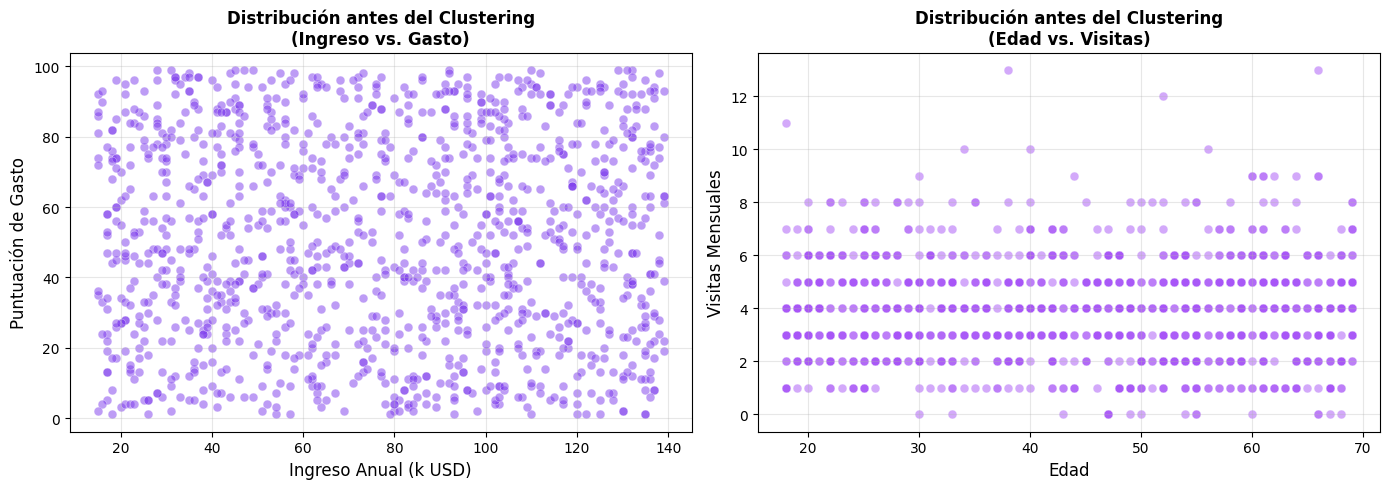

Exploración inicial completada.


In [2]:
# ─── Celda 2: Análisis exploratorio visual ────────────────────────────────────
features = ['edad', 'ingreso_anual_k_usd', 'puntuacion_gasto', 'visitas_mensuales']
X = df[features].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['ingreso_anual_k_usd'], df['puntuacion_gasto'],
                alpha=0.5, c='#7c3aed', edgecolors='white', linewidths=0.4, s=40)
axes[0].set_xlabel('Ingreso Anual (k USD)', fontsize=12)
axes[0].set_ylabel('Puntuación de Gasto', fontsize=12)
axes[0].set_title('Distribución antes del Clustering\n(Ingreso vs. Gasto)', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['edad'], df['visitas_mensuales'],
                alpha=0.5, c='#a855f7', edgecolors='white', linewidths=0.4, s=40)
axes[1].set_xlabel('Edad', fontsize=12)
axes[1].set_ylabel('Visitas Mensuales', fontsize=12)
axes[1].set_title('Distribución antes del Clustering\n(Edad vs. Visitas)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Exploración inicial completada.")


Datos estandarizados. Media ≈ -0.0000, Std ≈ 1.0000


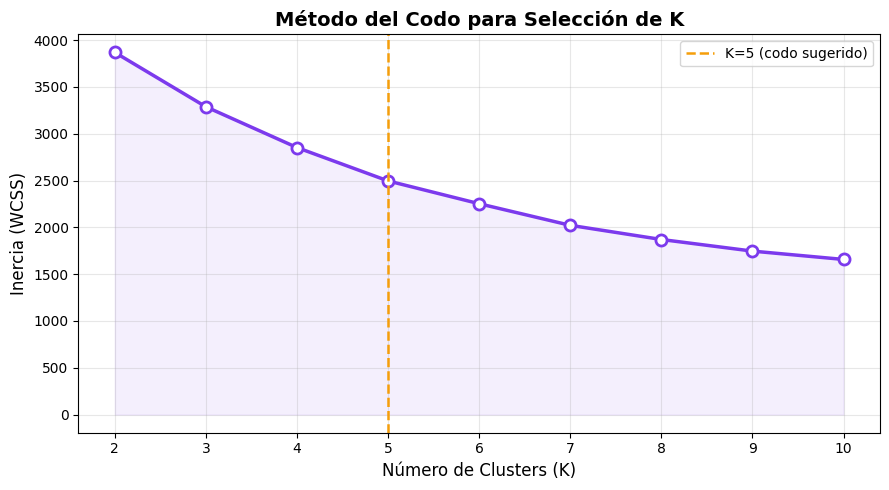

Inercias calculadas para K=2..10.


In [3]:
# ─── Celda 3: Estandarización + Método del Codo ──────────────────────────────
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(f"Datos estandarizados. Media ≈ {X_std.mean():.4f}, Std ≈ {X_std.std():.4f}")

# Método del Codo (2 a 10 clusters)
inercias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_std)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inercias, 'o-', color='#7c3aed', linewidth=2.5, markersize=8,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(list(K_range), inercias, alpha=0.08, color='#7c3aed')
ax.axvline(x=5, color='#f59e0b', linestyle='--', linewidth=1.8, label='K=5 (codo sugerido)')
ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Inercia (WCSS)', fontsize=12)
ax.set_title('Método del Codo para Selección de K', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Inercias calculadas para K=2..10.")


---
##### 🛠️ Práctica 1: ¿Dónde se dobla el codo?

La celda anterior dibujó la inercia para K = 2..10 y el texto dice que el codo está en K = 5. Vamos a **medirlo** en lugar de solo mirarlo. Usa las listas `inercias` y `K_range` ya calculadas:

1. Calcula la **mejora relativa** al pasar de K-1 a K: `(inercia[K-1] - inercia[K]) / inercia[K-1]`. Guárdala en una `pd.Series` llamada `mejora`, con el valor de K como índice (K = 3..10).
2. Encuentra el **primer K** cuya mejora relativa es menor al 10 % (`k_primero_bajo`).
3. El K recomendado es el **anterior** a ese (`k_codo`): el último K que todavía "valía la pena".
4. Comprueba que `k_codo` coincide con el K = 5 que usa el notebook.

In [ ]:
# Escribe tu código aquí

# inercias_arr = np.array(inercias)
# mejora = pd.Series(..., index=list(K_range)[1:])   # (anterior - actual) / anterior
# print((mejora * 100).round(1))

# k_primero_bajo = ...    # pista: mejora[mejora < 0.10].index[0]
# k_codo = ...
# print("K recomendado:", k_codo)

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
inercias_arr = np.array(inercias)

# 1) Mejora relativa de cada K frente al anterior (K = 3..10)
mejora = pd.Series((inercias_arr[:-1] - inercias_arr[1:]) / inercias_arr[:-1],
                   index=list(K_range)[1:])
print((mejora * 100).round(1).to_string())

# 2) Primer K cuya mejora cae por debajo del 10 %
k_primero_bajo = mejora[mejora < 0.10].index[0]

# 3) El K recomendado es el anterior
k_codo = k_primero_bajo - 1
print("\nK recomendado:", k_codo)

# 4) Coincide con el K elegido en el notebook
assert k_codo == 5
```
</details>

---


K-Means con K=5 | Inercia: 2495.66 | Silhouette Score: 0.2106


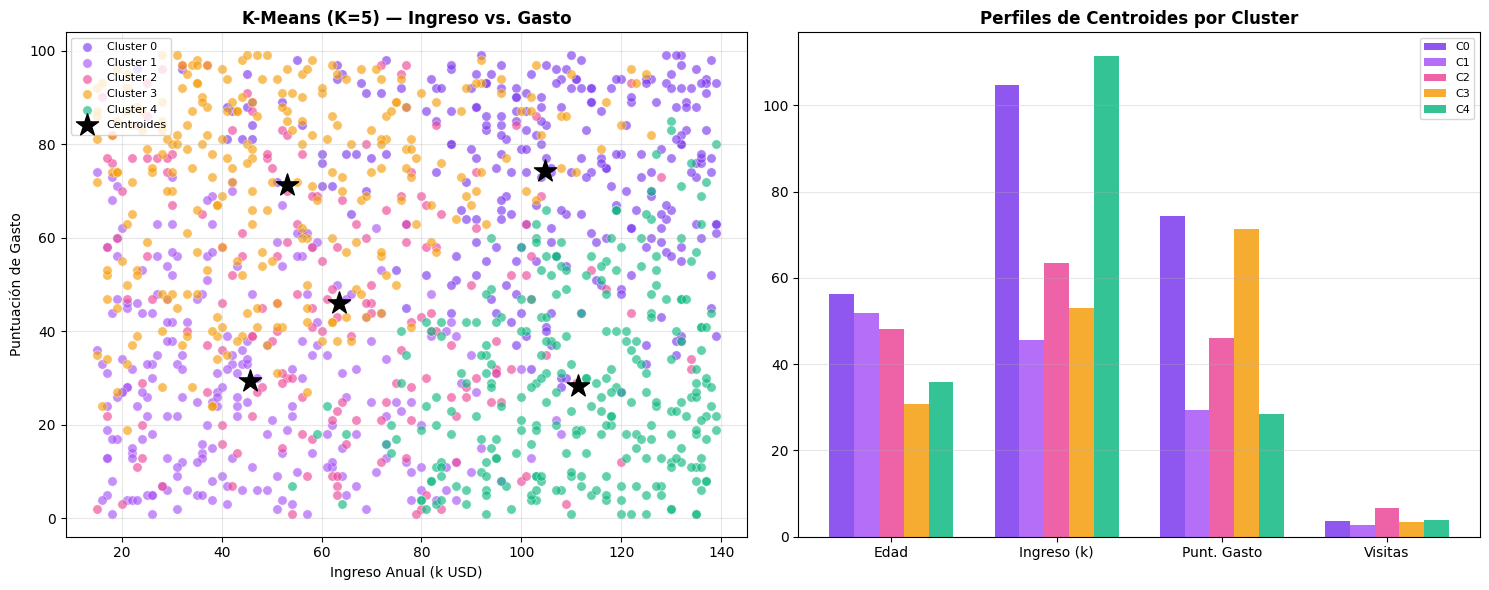


Conteo de clientes por cluster:
cluster
0    261
1    228
2    176
3    266
4    269
Name: count, dtype: int64


In [4]:
# ─── Celda 4: K-Means con K=5 y visualización ──────────────────────────────
K_OPTIMO = 5
km = KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=20, random_state=42)
labels = km.fit_predict(X_std)
df['cluster'] = labels

sil_score = silhouette_score(X_std, labels)
print(f"K-Means con K={K_OPTIMO} | Inercia: {km.inertia_:.2f} | Silhouette Score: {sil_score:.4f}")

# Visualización 2D (Ingreso vs Gasto)
palette = ['#7c3aed', '#a855f7', '#ec4899', '#f59e0b', '#10b981']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for k in range(K_OPTIMO):
    mask = labels == k
    axes[0].scatter(df.loc[mask, 'ingreso_anual_k_usd'], df.loc[mask, 'puntuacion_gasto'],
                    label=f'Cluster {k}', color=palette[k], alpha=0.65, s=45,
                    edgecolors='white', linewidths=0.4)
centroids_orig = scaler.inverse_transform(km.cluster_centers_)
axes[0].scatter(centroids_orig[:, 1], centroids_orig[:, 2], marker='*', s=280,
                c='black', zorder=5, label='Centroides')
axes[0].set_xlabel('Ingreso Anual (k USD)')
axes[0].set_ylabel('Puntuación de Gasto')
axes[0].set_title(f'K-Means (K={K_OPTIMO}) — Ingreso vs. Gasto', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Perfiles de centroides por cluster
centroid_df = pd.DataFrame(centroids_orig, columns=['edad', 'ingreso_k', 'punt_gasto', 'visitas'])
centroid_df.index.name = 'Cluster'
x = np.arange(4)
width = 0.15
cols = centroid_df.columns
for i in range(K_OPTIMO):
    axes[1].bar(x + i*width, centroid_df.iloc[i].values, width,
                label=f'C{i}', color=palette[i], alpha=0.85)
axes[1].set_xticks(x + width*2)
axes[1].set_xticklabels(['Edad', 'Ingreso (k)', 'Punt. Gasto', 'Visitas'])
axes[1].set_title('Perfiles de Centroides por Cluster', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("\nConteo de clientes por cluster:")
print(df['cluster'].value_counts().sort_index())


---
##### 🛠️ Práctica 2: Verifica la inercia a mano

En la sección 1 vimos que K-Means minimiza $J = \sum_{k}\sum_{x_i \in C_k} \| x_i - \mu_k \|^2$. Comprueba que `scikit-learn` calcula exactamente eso con el modelo `km` de la celda anterior (usa `X_std`, `labels` y `km.cluster_centers_`, que viven en el espacio **estandarizado**):

1. Recorre los `K_OPTIMO` clusters y suma las distancias euclidianas **al cuadrado** de cada punto a su centroide. Guarda el total en `J`.
2. Comprueba que `J` coincide con `km.inertia_`.
3. Comprueba que cada centroide es la **media** de los puntos de su cluster (el M-step de Lloyd).

In [ ]:
# Escribe tu código aquí

# J = 0.0
# for k in range(K_OPTIMO):
#     puntos_k = X_std[labels == k]
#     J += ...    # pista: ((puntos_k - km.cluster_centers_[k]) ** 2).sum()
# print(J, km.inertia_)

# Comprobaciones con assert (np.isclose para J, np.allclose para los centroides)

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Inercia a mano: suma de distancias al cuadrado al centroide
J = 0.0
for k in range(K_OPTIMO):
    puntos_k = X_std[labels == k]
    J += ((puntos_k - km.cluster_centers_[k]) ** 2).sum()
print(f"J a mano = {J:.4f} | km.inertia_ = {km.inertia_:.4f}")

# 2) Coincide con la inercia de scikit-learn
assert np.isclose(J, km.inertia_)

# 3) Cada centroide es la media de sus puntos
for k in range(K_OPTIMO):
    assert np.allclose(X_std[labels == k].mean(axis=0), km.cluster_centers_[k])
print("Inercia y centroides verificados.")
```
</details>

---


In [5]:
# ─── Celda 5: Interpretación de segmentos ────────────────────────────────────
resumen = df.groupby('cluster')[['edad', 'ingreso_anual_k_usd', 'puntuacion_gasto', 'visitas_mensuales']].mean().round(1)
resumen['tamanio'] = df.groupby('cluster').size()
print("=== Resumen de Segmentos de Clientes ===")
print(resumen.to_string())

# Etiquetas interpretativas
labels_seg = {
    0: "Jóvenes Alto Gasto",
    1: "Maduros Bajo Gasto",
    2: "Medianos Equilibrados",
    3: "Seniors Alto Ingreso",
    4: "Jóvenes Bajo Ingreso",
}
print("\n=== Interpretación de Segmentos ===")
for k, desc in labels_seg.items():
    row = resumen.loc[k]
    print(f"  Cluster {k} ({desc}): {int(row['tamanio'])} clientes | "
          f"Edad media {row['edad']} | Ingreso {row['ingreso_anual_k_usd']}k | Gasto {row['puntuacion_gasto']}")


=== Resumen de Segmentos de Clientes ===
         edad  ingreso_anual_k_usd  puntuacion_gasto  visitas_mensuales  tamanio
cluster                                                                         
0        56.4                104.7              74.4                3.6      261
1        51.9                 45.7              29.4                2.8      228
2        48.1                 63.4              46.0                6.8      176
3        30.7                 53.0              71.3                3.5      266
4        35.9                111.4              28.4                3.8      269

=== Interpretación de Segmentos ===
  Cluster 0 (Jóvenes Alto Gasto): 261 clientes | Edad media 56.4 | Ingreso 104.7k | Gasto 74.4
  Cluster 1 (Maduros Bajo Gasto): 228 clientes | Edad media 51.9 | Ingreso 45.7k | Gasto 29.4
  Cluster 2 (Medianos Equilibrados): 176 clientes | Edad media 48.1 | Ingreso 63.4k | Gasto 46.0
  Cluster 3 (Seniors Alto Ingreso): 266 clientes | Edad media 30.7 | 

---
##### 🛠️ Práctica 3: ¿A qué segmento pertenece un cliente nuevo?

Ya tienes el modelo `km`, el `scaler` y los nombres de segmento en `labels_seg`. Llega un cliente nuevo con **edad 30, ingreso anual 85 k USD, puntuación de gasto 70 y 6 visitas mensuales** (en ese orden, como en `features`).

1. Arma el arreglo `nuevo` de forma `(1, 4)` y **estandarízalo con el `scaler` ya ajustado** (con `transform`, no `fit_transform`: el cliente nuevo no debe cambiar la media ni la desviación).
2. Obtén su cluster con `km.predict` (`cluster_nuevo`).
3. Compruébalo a mano: calcula la distancia a cada fila de `km.cluster_centers_` y toma la menor (`np.argmin`). Debe dar el mismo cluster.
4. Imprime el nombre del segmento con `labels_seg`.

In [ ]:
# Escribe tu código aquí

# nuevo = np.array([[30, 85, 70, 6]])
# nuevo_std = scaler....(nuevo)
# cluster_nuevo = km....(nuevo_std)[0]

# Comprobación a mano: distancia a cada centroide
# dist_centroides = np.linalg.norm(km.cluster_centers_ - nuevo_std, axis=1)
# assert cluster_nuevo == np.argmin(dist_centroides)

# print(f"Cluster {cluster_nuevo}: {labels_seg[cluster_nuevo]}")

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Cliente nuevo, estandarizado con el scaler ya ajustado
nuevo = np.array([[30, 85, 70, 6]])
nuevo_std = scaler.transform(nuevo)

# 2) Cluster según el modelo
cluster_nuevo = km.predict(nuevo_std)[0]

# 3) Comprobación a mano: el centroide más cercano
dist_centroides = np.linalg.norm(km.cluster_centers_ - nuevo_std, axis=1)
assert cluster_nuevo == np.argmin(dist_centroides)

# 4) Nombre del segmento
print(f"Cluster {cluster_nuevo}: {labels_seg[cluster_nuevo]}")
print("Distancias a los centroides:", dist_centroides.round(2))
```
</details>

---


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos · Data Mining · Módulo 03</i><br>
    Docente: Santiago A. Zúñiga M. | <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
  </p>
</div>